Illustration using a toy convex example: $\min\limits_{x\in[-2,2]} \sum_{i=1}^{3} x_i^2$ subject to 
$\begin{bmatrix} x_1 & x_2 \\ x_3 & x_1 \end{bmatrix} \succeq 0$ and 
$x_1 + x_2 + x_3 = 0$. 
- (\textbf{a--b}) Projected contours of the objective function (w.r.t $x_1$ and $x_2$) in original and transformed spaces. 
- (\textbf{c--d}) Feasible regions defined by the semidefinite and equality constraints.}

In [68]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import seaborn as sns

sys.path.append('..')

from utils.homeomorphism import GaugeMap
torch.set_default_dtype(torch.float32)

In [134]:
# Define the convex set with inequality constraint: x1^2 - x2*x3 >= 0
# This can be written as a quadratic constraint: -x1^2 + x2*x3 <= 0
class ConvexSet:
    def __init__(self):
        self.nvar = 3
        # Quadratic constraint: 0.5 * x^T Q x + p^T x <= b
        # For x1^2 - x2*x3 >= 0, we need: -x1^2 + x2*x3 <= 0
        # Q matrix for -x1^2 + x2*x3:
        # Q = [[-2,  0,  0],
        #      [ 0,  0,  1],
        #      [ 0,  1,  0]]
        self.Qq = torch.tensor([[
            [-2.0, 0.0, 0.0],
            [0.0, 0.0, 0.5],
            [0.0, 0.5, 0.0]
        ]], dtype=torch.float32)
        
        self.pq = torch.zeros(1, 3)
        self.bq = torch.zeros(1)
        
        # Box constraints: -2 <= x <= 2
        self.L = torch.tensor([0,0,0])
        self.U = torch.tensor([2,2,2])
        
        # No SOC or linear constraints for this problem
        self.G = None
        self.h = None
        self.C = None
        self.d = None
        self.A = None
        self.b = None
        
    def constraint_x(self, x):
        """Evaluate constraint violations"""
        # Quadratic constraint
        quad_val = 0.5 * torch.sum(x.unsqueeze(1) * torch.matmul(self.Qq, x.T).permute(2,0,1), dim=-1)
        # Box constraints
        box_lower = self.L.view(1, -1) - x
        box_upper = x - self.U.view(1, -1)
        return torch.cat([quad_val, box_lower, box_upper], dim=-1)

convex_set = ConvexSet()
gauge_map = GaugeMap(convex_set, p_norm=2, x_origin=np.array([1., 0.5, 0.5]), smooth=False)
print("Convex set and gauge map created successfully!")

# Define the objective function: sum(x_i^2) for i=1,2,3
def objective_fn(x):
    """Compute objective value for points x (batch_size x 3)"""
    return torch.sum(x**2, dim=-1, keepdim=True)

Convex set and gauge map created successfully!


In [135]:
# Create grid in x1-x2 plane (x3 = 0 for projection)
x_range = np.linspace(-2, 2, 300)
X1, X2 = np.meshgrid(x_range, x_range)
# Compute objective values in original space (x3 = 0)
X1_flat = X1.ravel()
X2_flat = X2.ravel()
X3_flat = np.zeros_like(X1_flat)
points_orig = np.stack([X1_flat, X2_flat, X3_flat], axis=1)
points_orig_torch = torch.tensor(points_orig, dtype=torch.float32)
Obj_orig = objective_fn(points_orig_torch).reshape(X1.shape).numpy()

# # Map points to z-space using inverse map
Z_range = np.linspace(-3, 3, 300)
Z1, Z2 = np.meshgrid(Z_range, Z_range)
Z1_flat = Z1.ravel()
Z2_flat = Z2.ravel()
Z3_flat = np.zeros_like(Z1_flat)
points_trans = np.stack([Z1_flat, Z2_flat, Z3_flat], axis=1)
z_points = torch.tensor(points_trans, dtype=torch.float32)
Obj_trans = objective_fn(gauge_map.forward(z_points)).reshape(X1.shape).numpy()

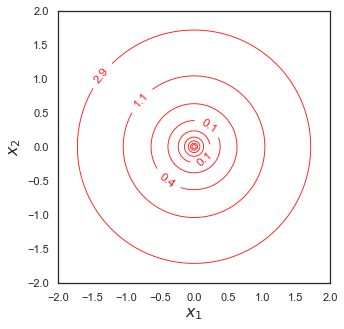

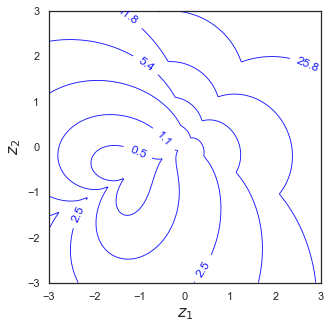

In [139]:
sns.set_theme(style="white")
# (a) Plot original space objective contours
fig1, ax1 = plt.subplots(1, 1, figsize=(5, 5)) # (a) objective contours wrt to x
levels = np.logspace(-3, np.log10(Obj_orig.max()), 10)
contour1 = ax1.contour(X1, X2, Obj_orig, levels=levels, colors='red', alpha=0.9, linewidths=0.9)
ax1.clabel(contour1, inline=True, fontsize=12, fmt='%.1f')
ax1.set_xlabel('$x_1$', fontsize=16, fontweight='bold')
ax1.set_ylabel('$x_2$', fontsize=16, fontweight='bold')
# ax1.set_title('(a) Original Space: Objective Contours', fontsize=14, fontweight='bold')
# ax1.grid(alpha=0.3)
ax1.set_aspect('equal')

fig2, ax2 = plt.subplots(1, 1, figsize=(5, 5)) # (b) transformed space, wrt to z
levels = np.logspace(-3, np.log10(Obj_trans.max()), 15)
contour2 = ax2.contour(Z1, Z2, Obj_trans, levels=levels, colors='blue', alpha=0.9, linewidths=0.9)
ax2.clabel(contour2, inline=True, fontsize=12, fmt='%.1f')
ax2.set_xlabel('$z_1$', fontsize=16, fontweight='bold')
ax2.set_ylabel('$z_2$', fontsize=16, fontweight='bold')
# ax2.set_title('(b) Transformed Space: Objective Contours', fontsize=14, fontweight='bold')
# ax2.grid(alpha=0.3)
ax2.set_aspect('equal')

In [148]:
# ========== Generate smooth surface meshes ==========

# 1. Unit sphere mesh (for z-space)
n_sphere = 2000
phi_mesh = np.linspace(0., 2*np.pi, n_sphere)
theta_mesh = np.linspace(0., np.pi, n_sphere)
Phi, Theta = np.meshgrid(phi_mesh, theta_mesh)

# Unit sphere coordinates
Z_sphere_x = np.sin(Theta) * np.cos(Phi)
Z_sphere_y = np.sin(Theta) * np.sin(Phi)
Z_sphere_z = np.cos(Theta)

# Flatten and convert to torch for mapping
z_sphere_points = np.stack([Z_sphere_x.ravel(), Z_sphere_y.ravel(), Z_sphere_z.ravel()], axis=1)
z_sphere_torch = torch.tensor(z_sphere_points, dtype=torch.float32)

# 2. Map unit sphere to x-space (convex set boundary)
x_from_sphere = gauge_map.forward(z_sphere_torch).numpy()
X_boundary_x = x_from_sphere[:, 0].reshape(n_sphere, n_sphere)
X_boundary_y = x_from_sphere[:, 1].reshape(n_sphere, n_sphere)
X_boundary_z = x_from_sphere[:, 2].reshape(n_sphere, n_sphere)
print(f"Convex set boundary mesh: {X_boundary_x.shape}")

# 3. Equality plane mesh in x-space: x_1 + x_2 + x_3 = 1
n_plane = 50
x1_range = np.linspace(-2, 2, n_plane)
x2_range = np.linspace(-2, 2, n_plane)
X1_plane, X2_plane = np.meshgrid(x1_range, x2_range)
X3_plane = 1 - X1_plane - X2_plane  # From equality: x3 = 1-x1 - x2

# Apply box constraints (set invalid points to NaN for clean visualization)
mask_box = (X3_plane >= -2) & (X3_plane <= 2)
X3_plane_masked = X3_plane.copy()
X3_plane_masked[~mask_box] = np.nan
print(f"Equality plane mesh: {X1_plane.shape}")

# 4. Map equality plane to z-space
eq_plane_points = np.stack([X1_plane.ravel(), X2_plane.ravel(), X3_plane.ravel()], axis=1)
eq_plane_torch = torch.tensor(eq_plane_points, dtype=torch.float32)
z_from_plane = gauge_map.inverse(eq_plane_torch).numpy()

Z_plane_x = z_from_plane[:, 0].reshape(n_plane, n_plane)
Z_plane_y = z_from_plane[:, 1].reshape(n_plane, n_plane)
Z_plane_z = z_from_plane[:, 2].reshape(n_plane, n_plane)

# Mask invalid regions in z-space as well
Z_plane_x[~mask_box] = np.nan
Z_plane_y[~mask_box] = np.nan
Z_plane_z[~mask_box] = np.nan
print(f"Mapped equality plane mesh: {Z_plane_x.shape}")

print("\n✓ All surface meshes generated!")

Convex set boundary mesh: (2000, 2000)
Equality plane mesh: (50, 50)
Mapped equality plane mesh: (50, 50)

✓ All surface meshes generated!


In [149]:
x_from_sphere

array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       ...,
       [1. , 0.5, 0.5],
       [1. , 0.5, 0.5],
       [1. , 0.5, 0. ]], dtype=float32)

/Users/liangenming/opt/anaconda3/envs/lem_app/lib/python3.7/site-packages/ipykernel_launcher.py:12: UserWarning: Z contains NaN values. This may result in rendering artifacts.
  if sys.path[0] == '':


(0.0, 2.0)

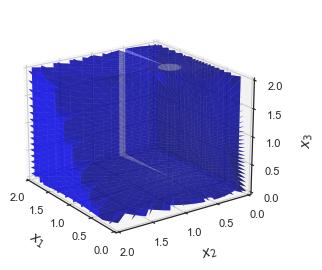

In [147]:
# Visualize surfaces in both spaces using SMOOTH plot_surface
sns.set_theme(style="white")

# ========== Left: Original x-space ==========
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(121, projection='3d')

# Plot convex set boundary (smooth surface)
surf1 = ax1.plot_surface(X_boundary_x, X_boundary_y, X_boundary_z, 
                         color='blue', alpha=0.6, 
                         edgecolor='none', shade=True,
                         label='Convex Set Boundary')

# Plot equality plane (smooth surface)
# surf2 = ax1.plot_surface(X1_plane, X2_plane, X3_plane_masked,
#                          color='coral', alpha=0.7,
#                          edgecolor='darkred', linewidth=0.3,
#                          label='Equality: $x_1+x_2+x_3=0$')

ax1.set_xlabel('$x_1$', fontsize=14, fontweight='bold', labelpad=10)
ax1.set_ylabel('$x_2$', fontsize=14, fontweight='bold', labelpad=10)
ax1.set_zlabel('$x_3$', fontsize=14, fontweight='bold', labelpad=10)
# ax1.set_title('(a) Original Space $\mathcal{X}$', fontsize=16, fontweight='bold', pad=15)
ax1.view_init(elev=20, azim=145)
# ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 2])
ax1.set_ylim([0, 2])
ax1.set_zlim([0, 2])


/Users/liangenming/opt/anaconda3/envs/lem_app/lib/python3.7/site-packages/ipykernel_launcher.py:10: UserWarning: Z contains NaN values. This may result in rendering artifacts.
  # Remove the CWD from sys.path while we load stuff.


(-1.0, 1.0)

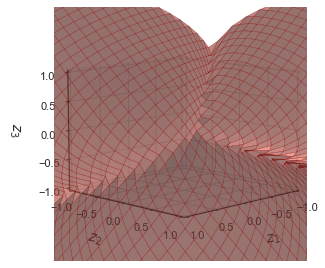

In [158]:


# ========== Right: Transformed z-space ==========
fig = plt.figure(figsize=(10, 10))
ax2 = fig.add_subplot(122, projection='3d')


# Plot mapped equality plane (smooth surface)
surf4 = ax2.plot_surface(Z_plane_x, Z_plane_y, Z_plane_z,
                         color='salmon', alpha=0.7,
                         edgecolor='darkred', linewidth=0.3,
                         label='Mapped Equality Plane')
# Plot unit sphere (smooth surface)
# surf3 = ax2.plot_surface(Z_sphere_x, Z_sphere_y, Z_sphere_z,
#                          color='lightblue', alpha=0.2,
#                          edgecolor='none', shade=True,
#                          label='Unit Sphere Boundary')

ax2.set_xlabel('$z_1$', fontsize=14, fontweight='bold', labelpad=10)
ax2.set_ylabel('$z_2$', fontsize=14, fontweight='bold', labelpad=10)
ax2.set_zlabel('$z_3$', fontsize=14, fontweight='bold', labelpad=10)
# ax2.set_title('(b) Transformed Space $\mathcal{Z}$', fontsize=16, fontweight='bold', pad=15)
ax2.view_init(elev=10, azim=45)
# ax2.grid(True, alpha=0.3)

# Set equal aspect ratio for both plots
ax2.set_xlim([-1, 1])
ax2.set_ylim([-1, 1])
ax2.set_zlim([-1, 1])
